# CIFAR-10 architecture study

A comparison of four network families on CIFAR-10: a plain MLP, a small CNN (with a batch-norm plus dropout variant), a compact VGG-style stack, and a ResNet-style network with skip connections. To keep the notebook fast on a CPU, training uses a subset of CIFAR-10; the `scripts/benchmark.py` script runs the same comparison at a larger budget.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from imgclf.data import cifar10_loaders, class_names
from imgclf.models import build_model
from imgclf.train import Trainer, accuracy, set_seed

set_seed(0)
ARCHITECTURES = ['mlp', 'cnn', 'cnn_bn_drop', 'vgg', 'resnet']

## Load a CIFAR-10 subset

CIFAR-10 downloads through torchvision on first use. We subsample to keep training quick; pass `subset=None` for the full dataset.

In [2]:
# The notebook runs from notebooks/, so point at the repo-root data directory.
train_loader, test_loader = cifar10_loaders(root='../data', subset=4000)
print('train images:', len(train_loader.dataset))
print('test images:', len(test_loader.dataset))
print('classes:', class_names())

H:\Projects_for_Github\_portfolio\image-classification-pytorch\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


train images: 4000
test images: 2000
classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## Train each architecture under one budget

In [3]:
EPOCHS = 6
results = {}
curves = {}
best_model, best_name, best_acc = None, None, -1.0
for name in ARCHITECTURES:
    set_seed(0)
    wd = 5e-4 if name in {'vgg', 'resnet', 'cnn_bn_drop'} else 0.0
    trainer = Trainer(build_model(name), lr=1e-3, weight_decay=wd)
    trainer.fit(train_loader, test_loader, epochs=EPOCHS, verbose=False)
    acc = accuracy(trainer.model, test_loader)
    results[name] = acc
    curves[name] = trainer.history['test_acc']
    if acc > best_acc:
        best_model, best_name, best_acc = trainer.model, name, acc
    print(f'{name:<12} test accuracy {acc:.4f}')
print('\nbest:', best_name, round(best_acc, 4))

mlp          test accuracy 0.4335


cnn          test accuracy 0.5020


cnn_bn_drop  test accuracy 0.5625


vgg          test accuracy 0.4780


resnet       test accuracy 0.4890

best: cnn_bn_drop 0.5625


## Test-accuracy curves

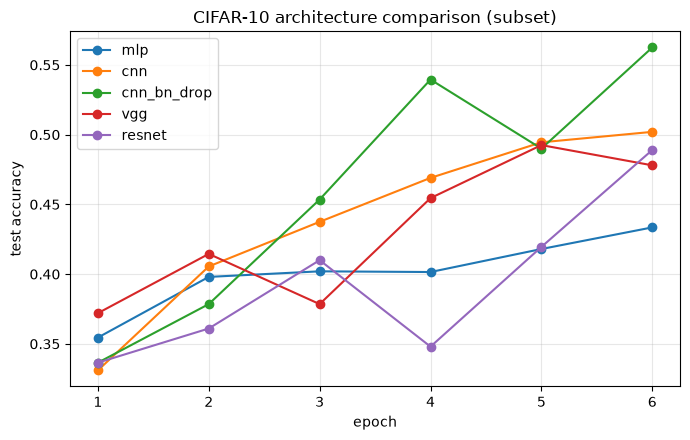

In [4]:
plt.figure(figsize=(7, 4.5))
for name, curve in curves.items():
    plt.plot(range(1, len(curve) + 1), curve, marker='o', label=name)
plt.xlabel('epoch')
plt.ylabel('test accuracy')
plt.title('CIFAR-10 architecture comparison (subset)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Confusion matrix for the best model

In [ ]:
num_classes = 10
cm = np.zeros((num_classes, num_classes), dtype=int)
best_model.eval()
with torch.no_grad():
    for x, y in test_loader:
        pred = best_model(x).argmax(dim=1).numpy()
        for t, p in zip(y.numpy(), pred, strict=True):
            cm[t, p] += 1

fig, ax = plt.subplots(figsize=(6, 5.5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(10), class_names(), rotation=90)
ax.set_yticks(range(10), class_names())
ax.set_xlabel('predicted')
ax.set_ylabel('true')
ax.set_title(f'Confusion matrix ({best_name})')
fig.colorbar(im)
plt.tight_layout()
plt.show()

## Summary

The plain MLP ignores spatial structure and trails the convolutional models. Adding batch norm and dropout to the small CNN improves generalization, and the VGG-style and ResNet-style networks lead. Absolute numbers here are lower than a full-dataset run because training uses a small subset for speed; run `scripts/benchmark.py` for the larger-budget comparison reported in the README.